C:\Users\Admin\AppData\Local\Temp\ipykernel_2312\2886795259.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col].str.replace(r'[$,%]', '', regex=True), errors='ignore')


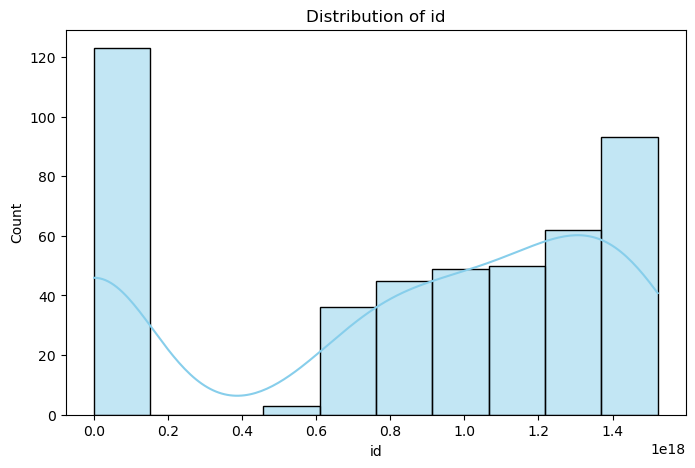

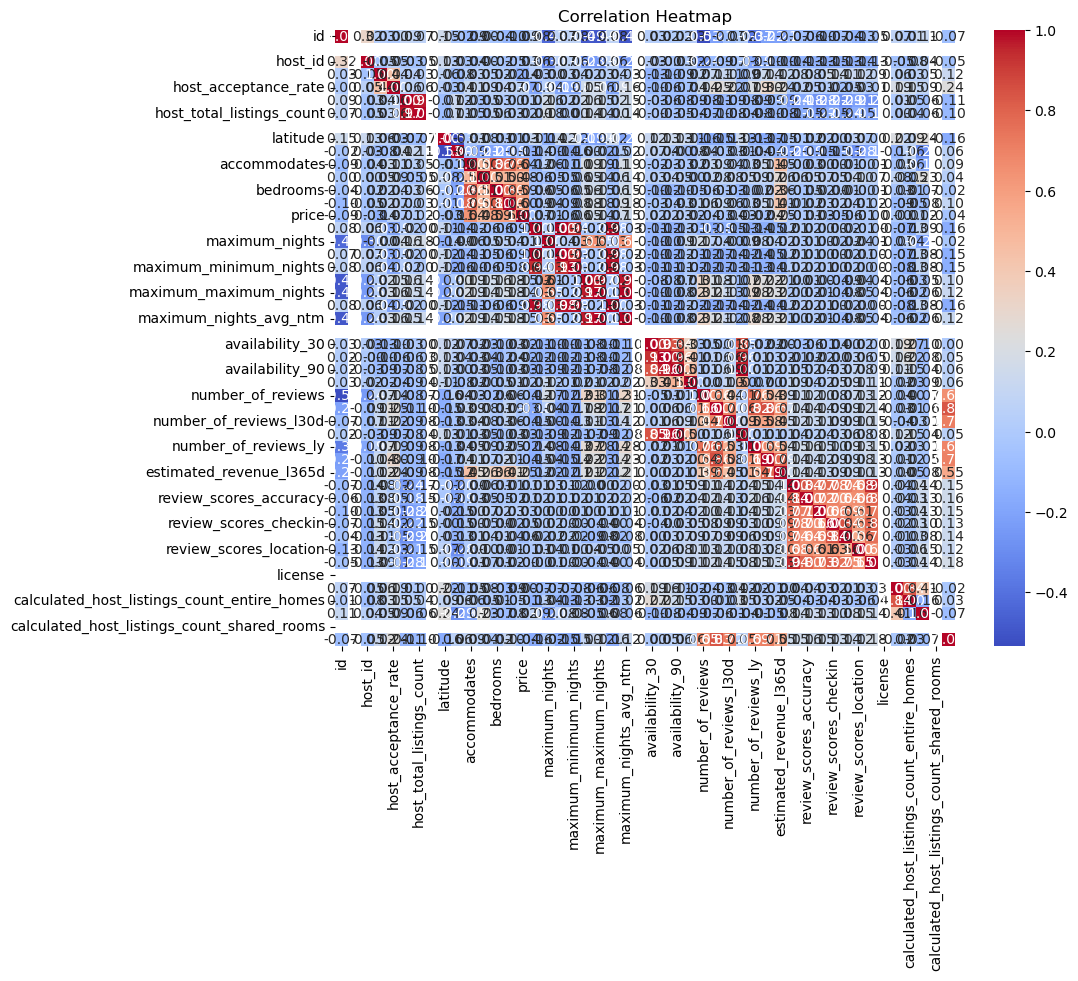

C:\Users\Admin\AppData\Local\Temp\ipykernel_2312\2886795259.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=categorical_cols[0], data=df[df[categorical_cols[0]].isin(top_values)], palette='viridis')


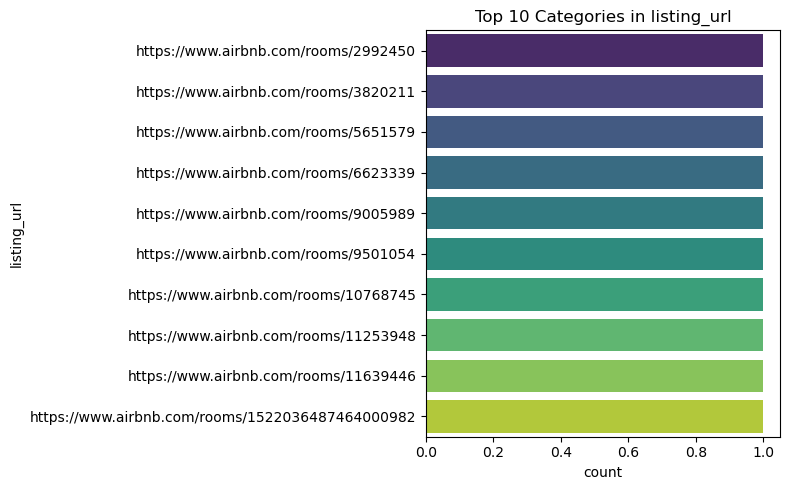

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('listings.csv')

df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col].str.replace(r'[$,%]', '', regex=True), errors='ignore')
        except:
            pass

numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
df[categorical_cols] = df[categorical_cols].fillna('Unknown')

if not numeric_cols.empty:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[numeric_cols[0]], kde=True, color='skyblue')
    plt.title(f'Distribution of {numeric_cols[0]}')
    plt.show()

if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Heatmap')
    plt.show()

if not categorical_cols.empty:
    plt.figure(figsize=(8, 5))
    top_values = df[categorical_cols[0]].value_counts().nlargest(10).index
    sns.countplot(y=categorical_cols[0], data=df[df[categorical_cols[0]].isin(top_values)], palette='viridis')
    plt.title(f'Top 10 Categories in {categorical_cols[0]}')
    plt.tight_layout()
    plt.show()